# QR Code & Barcode Scanner



## 1. Imports & Dependencies

In [14]:
!pip install pyzbar
!sudo apt-get update && sudo apt-get install -y zbar-tools libzbar-dev

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libzbar-dev is already the newest version (0.23.92-4build2).
zbar-tools is already the newest 

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode
from IPython.display import display
from PIL import Image
import ipywidgets as widgets
import io
import os


print("All dependencies loaded successfully.")

All dependencies loaded successfully.


## 2. Image Loading

In [16]:
def load_image(path: str) -> np.ndarray:
    """
    Load an image from disk using OpenCV.

    Parameters
    ----------
    path : str
        Path to the image file (jpg, png, jpeg).

    Returns
    -------
    np.ndarray
        BGR image array, or raises FileNotFoundError if loading fails.
    """
    # Attempt to read the image from disk
    img = cv2.imread(path)
     # Check if the image was successfully loaded
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {path}")
     # Print image information for debugging/verification
    print(f"Image loaded: {path} | Shape: {img.shape}")
    return img


def show_image(img: np.ndarray, title: str = "Image") -> None:
    """
    Display a BGR OpenCV image inline in the notebook.

    Parameters
    ----------
    img : np.ndarray
        BGR image array.
    title : str
        Title shown above the image.
    """
    # Convert image from BGR (OpenCV format) to RGB (Matplotlib format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Preprocessing

In [17]:
def preprocess_image(img):
        # Conversion de l'image couleur (BGR) en nuances de gris (Gray)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Binarisation d'Otsu : sépare le noir et le blanc de façon optimale
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Application d'un flou Gaussien pour réduire le bruit numérique
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # Algorithme Canny pour détecter les contours (lignes de contraste)
        edges = cv2.Canny(blur, 50, 150)

        # Dilatation et Érosion : épaissit les lignes pour boucher les trous dans les contours
        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        edges = cv2.erode(edges, kernel, iterations=1)

        # Calcul du gradient de Sobel : accentue les zones de fortes variations (comme les barres d'un code)
        grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=-1)
        grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=-1)
        gradient = cv2.convertScaleAbs(cv2.subtract(grad_x, grad_y)) # Soustraction pour isoler les motifs verticaux

        # Flou sur le gradient pour regrouper les barres du code-barres en un bloc
        blurred_grad = cv2.GaussianBlur(gradient, (9, 9), 0)
        _, grad_thresh = cv2.threshold(blurred_grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Opération "Closing" : fusionne les barres proches pour créer une zone rectangulaire pleine
        kernel_bar = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
        closed = cv2.morphologyEx(grad_thresh, cv2.MORPH_CLOSE, kernel_bar)
        closed = cv2.erode(closed, None, iterations=4) # Nettoyage des petits bruits
        closed = cv2.dilate(closed, None, iterations=4) # Rétablissement de la taille après érosion

        return {"gray": gray, "thresh": thresh, "edges": edges, "closed": closed}

## 4. QR Code Detection

In [18]:
def detect_qr_local(img, preprocessed):
        qr_detector = cv2.QRCodeDetector() # Initialisation du moteur de détection QR d'OpenCV
        results = []
        edges = preprocessed["edges"]

        # Recherche des contours dans l'image traitée par Canny
        contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            # On ignore les zones trop petites pour être un QR Code
            if cv2.contourArea(cnt) < 1000: continue

            # On calcule le rectangle englobant le contour
            x, y, w, h = cv2.boundingRect(cnt)
            ratio = w / float(h)

            # Un QR Code est toujours approximativement carré (ratio proche de 1)
            if not (0.8 < ratio < 1.2): continue

            # On découpe cette zone (ROI = Region of Interest) de l'image
            roi = img[y:y + h, x:x + w]
            if roi.size == 0: continue

            # Prétraitement spécifique de la petite zone pour faciliter la lecture
            roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            _, roi_thresh = cv2.threshold(roi_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # Ajout d'une marge blanche (Quiet Zone) indispensable pour les lecteurs de codes
            padding = int(w * 0.15)
            roi_padded = cv2.copyMakeBorder(roi_thresh, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=255)

            # Agrandissement pour que les petits QR soient lisibles
            roi_big = cv2.resize(roi_padded, (400, 400), interpolation=cv2.INTER_NEAREST)

            # Test de décodage sur la version originale et la version agrandie
            for candidate in [roi_padded, roi_big]:
                data_local, _, _ = qr_detector.detectAndDecode(candidate)
                if data_local:
                    res_str = f"[QR] {data_local}"
                    if res_str not in results:
                        results.append(res_str)
                        # Dessin d'un rectangle vert si succès
                        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 4)
                    break
        return results, img

## 5. Barcode Detection

In [19]:
def detect_barcodes(img, preprocessed):
        results = []
        closed = preprocessed["closed"]
        # Recherche des blocs rectangulaires potentiels pour les codes-barres 1D
        bar_contours, _ = cv2.findContours(closed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for c in bar_contours:
            # On ignore les blocs trop petits
            if cv2.contourArea(c) < 3000: continue

            # Calcul du rectangle incliné pour suivre l'angle du code-barres
            rect = cv2.minAreaRect(c)
            box = np.int32(cv2.boxPoints(rect)) # Coordonnées des 4 coins

            # Découpe de la zone
            x, y, w, h = cv2.boundingRect(box)
            roi = img[max(0,y):y+h, max(0,x):x+w]
            if roi.size == 0: continue

            # Amélioration du contraste pour les codes-barres (Égalisation d'histogramme)
            roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            roi_eq = cv2.equalizeHist(roi_gray)
            _, roi_thresh = cv2.threshold(roi_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            roi_big = cv2.resize(roi_thresh, None, fx=2, fy=2)

            # Test du moteur PyZbar sur plusieurs versions de la zone
            candidates = [roi, roi_gray, roi_eq, roi_thresh, roi_big]
            decoded = []
            for cand in candidates:
                decoded = decode(cand)
                if decoded: break

            for barcode in decoded:
                # On ignore les QR ici car ils sont gérés par la fonction précédente
                if barcode.type == "QRCODE": continue
                barcode_data = barcode.data.decode("utf-8")
                results.append(f"[{barcode.type}] {barcode_data}")
                # Dessin du contour en rouge pour les codes-barres
                cv2.drawContours(img, [box], -1, (0, 0, 255), 3)

        return results, img

## 6. Full Pipeline

In [20]:
def run_pipeline(image_path: str, verbose: bool = True) -> dict:
    """
    Run the complete QR/Barcode detection pipeline on a single image.

    Parameters
    ----------
    image_path : str
        Path to the input image.
    verbose : bool
        If True, display annotated image and print results.

    Returns
    -------
    dict with keys:
        - 'results'         : list of decoded strings
        - 'annotated_image' : BGR image with drawn detections
    """
    # Step 1: Load
    img = load_image(image_path)
    annotated = img.copy()

    # Step 2: Preprocess
    preprocessed = preprocess_image(annotated)

    # Step 3: QR - Global scan


    # Step 4: QR - Local ROI scan
    qr_local, annotated = detect_qr_local(annotated, preprocessed)

    # Step 5: Barcode scan
    barcodes, annotated = detect_barcodes(annotated, preprocessed)

    all_results =   qr_local + barcodes

    if verbose:
        show_image(annotated, title="Detection Results")
        print("\n=== DETECTED CODES ===")
        if all_results:
            for r in all_results:
                print(" •", r)
        else:
            print(" No QR code or barcode detected.")

    return {"results": all_results, "annotated_image": annotated}

## 7. Example Run



Image loaded: /content/BARCODE2.png | Shape: (357, 672, 3)


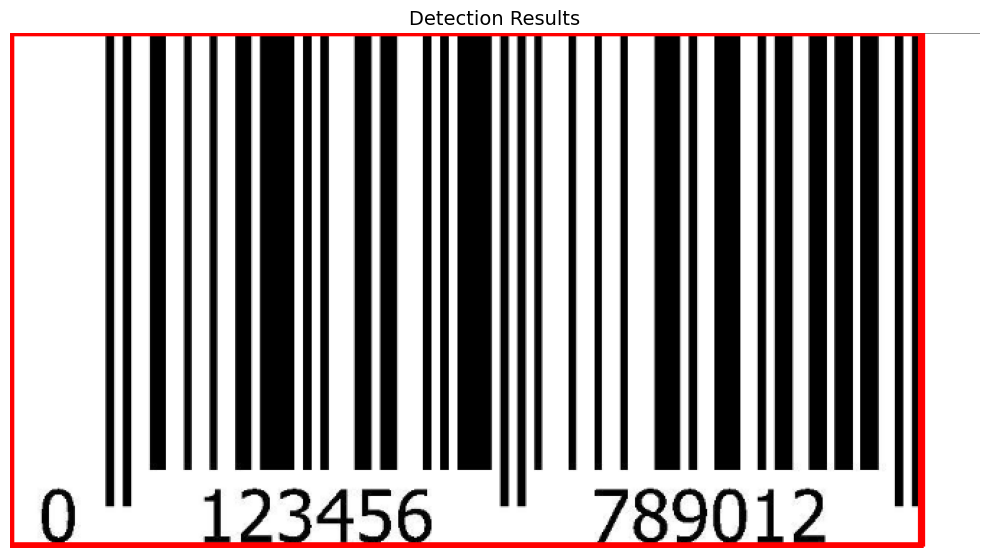


=== DETECTED CODES ===
 • [EAN13] 0123456789012


In [26]:
IMAGE_PATH = "/content/BARCODE2.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

Image loaded: /content/BARCODE3.png | Shape: (286, 650, 3)


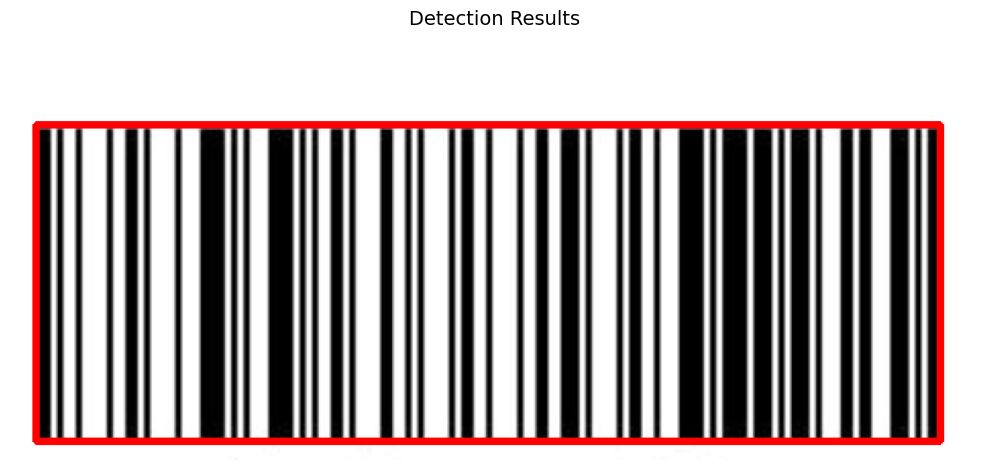


=== DETECTED CODES ===
 • [CODE128] google.com


In [22]:

IMAGE_PATH = "/content/BARCODE3.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

Image loaded: /content/QR1.png | Shape: (225, 225, 3)


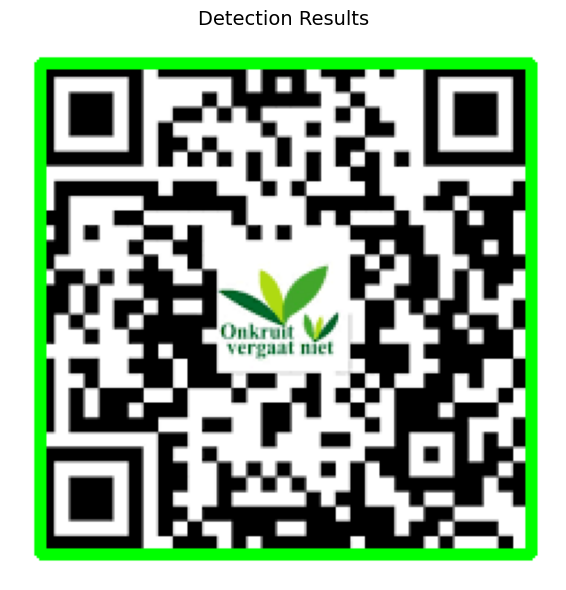


=== DETECTED CODES ===
 • [QR] https://onkruitvergaatniet.nl/qr-pierson


In [23]:

IMAGE_PATH = "/content/QR1.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

Image loaded: /content/QR2.png | Shape: (1536, 1536, 3)


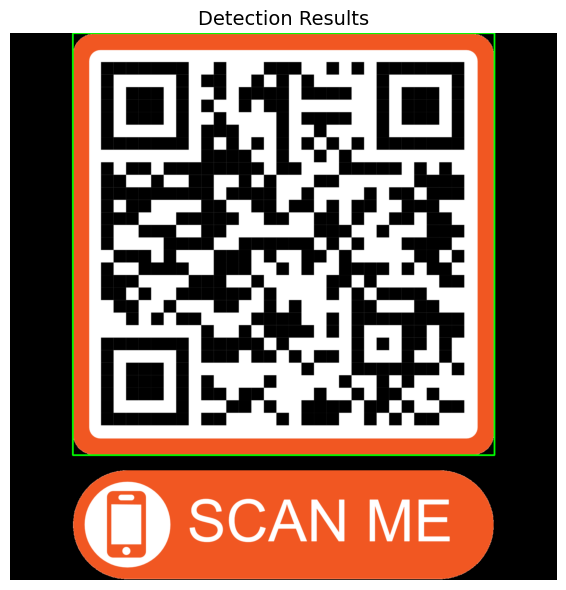


=== DETECTED CODES ===
 • [QR] https://me-qr.com/FbwC4Yxw


In [24]:

IMAGE_PATH = "/content/QR2.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

## 8. Interactive Widget Interface (ipywidgets)

Use the widget below to upload an image directly in the notebook and run the pipeline interactively.

In [25]:
# ── Upload widget ──────────────────────────────────────────────────────────────
uploader = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
    button_style="info",
)

run_button = widgets.Button(
    description="Scan",
    button_style="success",
    icon="search",
)

output_area = widgets.Output()

def on_scan_clicked(b):
    output_area.clear_output()
    with output_area:
        if not uploader.value:
            print("Please upload an image first.")
            return

        # Decode uploaded bytes to OpenCV image
        uploaded_file = list(uploader.value.values())[0]
        img_bytes = uploaded_file["content"]
        np_arr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

        if img is None:
            print("Failed to decode the uploaded image.")
            return

        print(f"Image loaded | Shape: {img.shape}")
        annotated = img.copy()
        preprocessed = preprocess_image(annotated)


        qr_local,  annotated = detect_qr_local(annotated, preprocessed)
        barcodes,  annotated = detect_barcodes(annotated, preprocessed)

        all_results = qr_local + barcodes

        show_image(annotated, title="Detection Results")

        print("\n=== DETECTED CODES ===")
        if all_results:
            for r in all_results:
                print(" •", r)
        else:
            print(" No QR code or barcode detected.")

run_button.on_click(on_scan_clicked)

display(widgets.VBox([uploader, run_button, output_area]))